# **Autores**

David Tinoco Romero - A01801491

Emilio Páez De la Mora - A01801224


# **Importar dataset**

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

# **Preprocesamiento de datos**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

In [ ]:
#Semilla
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [ ]:
#Codificar las etiquetas a numerico
le = LabelEncoder()
y = le.fit_transform(y)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
#División del dataset, 80% datos de entrenamiento y 20% datos de validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [ ]:
#Características escaladas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Definición del modelo de Aprendizaje Supervisado (Red Neuronal)**

In [ ]:
model_original  = Sequential()
model_original.add(Dense(6, activation='relu', input_shape=(X_train.shape[1],)))
model_original.add(Dropout(0.3))    #regularización para evitar overfitting
model_original.add(Dense(4, activation='relu'))
model_original.add(Dropout(0.3))    #regularización para evitar overfitting
model_original.add(Dense(2, activation='relu'))
model_original.add(Dropout(0.3))    #regularización para evitar overfitting
model_original.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Learning rate
optimizer = Adam(learning_rate=0.001)

In [ ]:
model_original.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

#Entrenamiento
history = model_original.fit(
    X_train, y_train,
    epochs=150,
    batch_size=15,
    validation_data=(X_test, y_test),
    verbose=0
)

#Predicción en X_test
X_test = np.array(X_test)
predictions = (model_original.predict(X_test) > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
model_original.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │           186 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683 (2.67 KB)

 Trainable params: 227 (908.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 456 (1.79 KB)

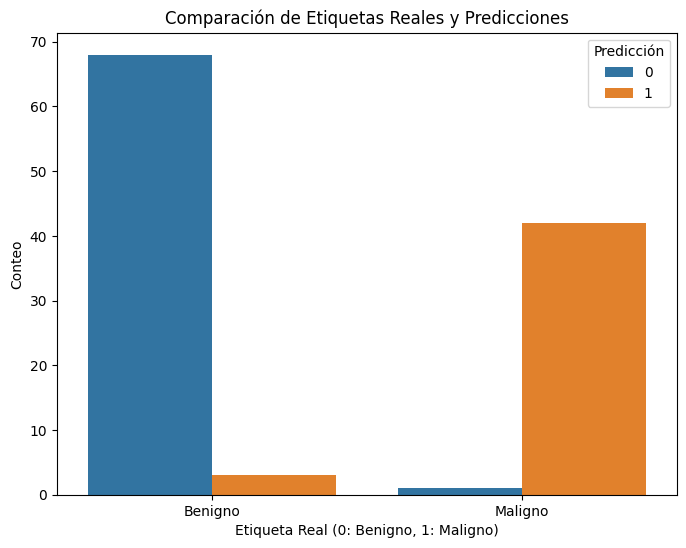

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame para visualizar las predicciones vs. reales
df_comparison = pd.DataFrame({'Real': y_test, 'Predicción': predictions.flatten()})

plt.figure(figsize=(8, 6))
sns.countplot(x='Real', hue='Predicción', data=df_comparison)
plt.title('Comparación de Etiquetas Reales y Predicciones')
plt.xlabel('Etiqueta Real (0: Benigno, 1: Maligno)')
plt.ylabel('Conteo')
plt.xticks([0, 1], ['Benigno', 'Maligno'])
plt.legend(title='Predicción')
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

for i in range(5):
	# Access the i-th row of the DataFrame X using .iloc and convert it to a list
	# Access the i-th prediction (which is a 2D array, so use [0] to get the scalar value)
	print('%s => %d (expected %d)' % (X.iloc[i].tolist(), predictions[i][0], y[i]))

[17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419, 0.07871, 1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193, 25.38, 17.33, 184.6, 2019.0, 0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189] => 0 (expected 1)
[20.57, 17.77, 132.9, 1326.0, 0.08474, 0.07864, 0.0869, 0.07017, 0.1812, 0.05667, 0.5435, 0.7339, 3.398, 74.08, 0.005225, 0.01308, 0.0186, 0.0134, 0.01389, 0.003532, 24.99, 23.41, 158.8, 1956.0, 0.1238, 0.1866, 0.2416, 0.186, 0.275, 0.08902] => 1 (expected 1)
[19.69, 21.25, 130.0, 1203.0, 0.1096, 0.1599, 0.1974, 0.1279, 0.2069, 0.05999, 0.7456, 0.7869, 4.585, 94.03, 0.00615, 0.04006, 0.03832, 0.02058, 0.0225, 0.004571, 23.57, 25.53, 152.5, 1709.0, 0.1444, 0.4245, 0.4504, 0.243, 0.3613, 0.08758] => 1 (expected 1)
[11.42, 20.38, 77.58, 386.1, 0.1425, 0.2839, 0.2414, 0.1052, 0.2597, 0.09744, 0.4956, 1.156, 3.445, 27.23, 0.00911, 0.07458, 0.05661, 0.01867, 0.05963, 0.009208, 14.91, 26.5, 98.87, 567.7, 0.2098, 0.8663, 0.6869, 0.2575, 0.

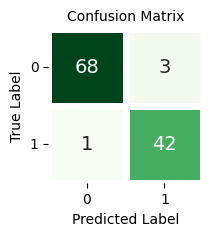


Precision: 0.9333, Recall: 0.9767, F1 Score: 0.9545, Accuracy: 0.9649


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)

# Las listas deben de ser con el mismo número de elementos que las clases
df1 = pd.DataFrame(columns=["0","1"], index= ["0","1"], data= cm )

# Matriz del mismo tamaño que el número de clases
f,ax = plt.subplots(figsize=(2,2))

sns.heatmap(df1, annot=True,cmap="Greens", fmt= '.0f',
            ax=ax,linewidths = 5, cbar = False,annot_kws={"size": 14})
plt.xlabel("Predicted Label")
plt.xticks(size = 10)
plt.yticks(size = 10, rotation = 0)
plt.ylabel("True Label")
plt.title("Confusion Matrix", size = 10)
plt.show()


precision_orig = precision_score(y_test, predictions)
recall_orig = recall_score(y_test, predictions)
f1_orig = f1_score(y_test, predictions)
accuracy_orig = accuracy_score(y_test, predictions)
print(f"\nPrecision: {precision_orig:.4f}, Recall: {recall_orig:.4f}, F1 Score: {f1_orig:.4f}, Accuracy: {accuracy_orig:.4f}")

# **Definición del modelo de Aprendizaje No Supervisado (K-means)**

In [ ]:
#Método utilizado K-means

#Librerias
!pip install kneed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator

In [ ]:
features, true_labels = X, y
features[:5]

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
true_labels[:5]

array([1, 1, 1, 1, 1])

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

kmeans = KMeans(
    n_clusters=3,
    init="random",
    n_init=10,
    max_iter=300,
    random_state=42
)
kmeans.fit(scaled_features)


KMeans(init='random', n_clusters=3, n_init=10, random_state=42)

In [ ]:
# The lowest SSE value
kmeans.inertia_

10061.797818243693

In [ ]:
# Final locations of the centroid
kmeans.cluster_centers_

array([[ 1.61908207,  0.62661289,  1.6240009 ,  1.66315361,  0.39856469,
         0.93061442,  1.23933718,  1.48697008,  0.43217049, -0.2869193 ,
         1.44128466,  0.0938201 ,  1.40538059,  1.42350487, -0.07267167,
         0.47907229,  0.43975291,  0.78783453,  0.05442714,  0.11903767,
         1.66674915,  0.54289966,  1.65684176,  1.68494744,  0.33688865,
         0.67029147,  0.88661143,  1.27318238,  0.30034644,  0.08406585],
       [-0.17232895,  0.17898672, -0.10074437, -0.22001438,  0.84922567,
         1.03543143,  0.78100563,  0.49942706,  0.75279302,  1.18398151,
        -0.08502958,  0.02340245, -0.01783062, -0.17235697,  0.43965152,
         1.07468661,  0.89050757,  0.75214074,  0.28645615,  1.0264176 ,
        -0.08822954,  0.31146754, -0.00701494, -0.15647731,  0.96915045,
         1.17977172,  1.0450547 ,  0.74299822,  0.80991644,  1.38461312],
       [-0.44809508, -0.2418554 , -0.46954224, -0.44831604, -0.358676  ,
        -0.57356749, -0.59729151, -0.59473375, -0

In [ ]:
# The number of iterations required to converge
kmeans.n_iter_

13

In [ ]:
kmeans.labels_[:5]

array([0, 0, 0, 1, 0], dtype=int32)

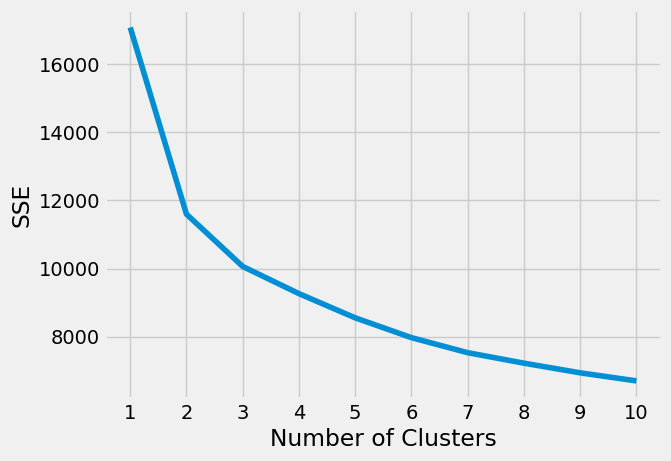

In [ ]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
kl = KneeLocator(
    range(1, 11), sse, curve="convex", direction="decreasing")

kl.elbow

np.int64(3)

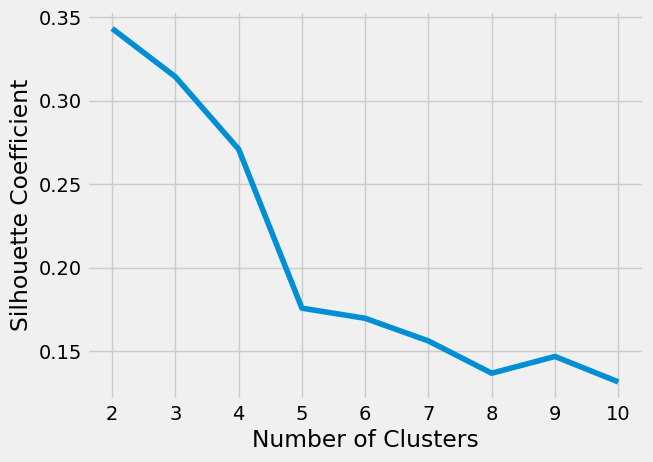

In [ ]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

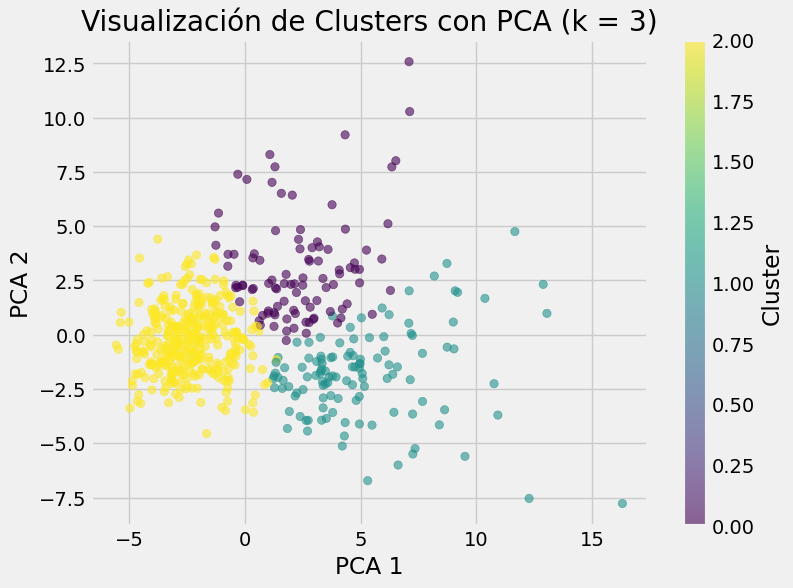

In [ ]:
# Visualización de los 3 clusters

# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled_features)

# Ejecutar KMeans con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

# Visualización de los 3 clusters

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title("Visualización de Clusters con PCA (k = 3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
# Tabla de contingencia
df_clusters = pd.DataFrame({
    'Diagnóstico Real': true_labels,
    'Cluster': cluster_labels
})

tabla = pd.crosstab(df_clusters['Cluster'], df_clusters['Diagnóstico Real'],
                    rownames=['Cluster (K-means)'],
                    colnames=['Diagnóstico Real'])
print(tabla)


Diagnóstico Real     0    1
Cluster (K-means)          
0                   36   61
1                    0  118
2                  321   33


Aunque el clustering no logra una separación perfecta, podemos observar que si encunetra agrupaciones que tienen una relqacion sugnufucativa cin los diagnosticos reales.

El modelo K-means detectó 3 clusters, en este caso K-means no sabe que existen solamente dos clases clínicas de tumores (benigno y maligno), esto quiere decir que estas agrupaciones naturales estan solamente basadas en similitudes matemáticas (distancias), lo que significa que se podría interpretar de otra forma:

1. Cluster 1: Tumores probablemente benignos
2. Cluster 2: Tumores posiblemente malignos
3. Cluster 3: Casos intermedios o atípicos



In [ ]:
# Calcular Adjusted Rand Index entre las etiquetas reales y las asignadas por KMeans
ari_score = adjusted_rand_score(true_labels, cluster_labels)

print(f"\nAdjusted Rand Index (ARI) para K-means: {ari_score:.4f}")


Adjusted Rand Index (ARI) para K-means: 0.5389


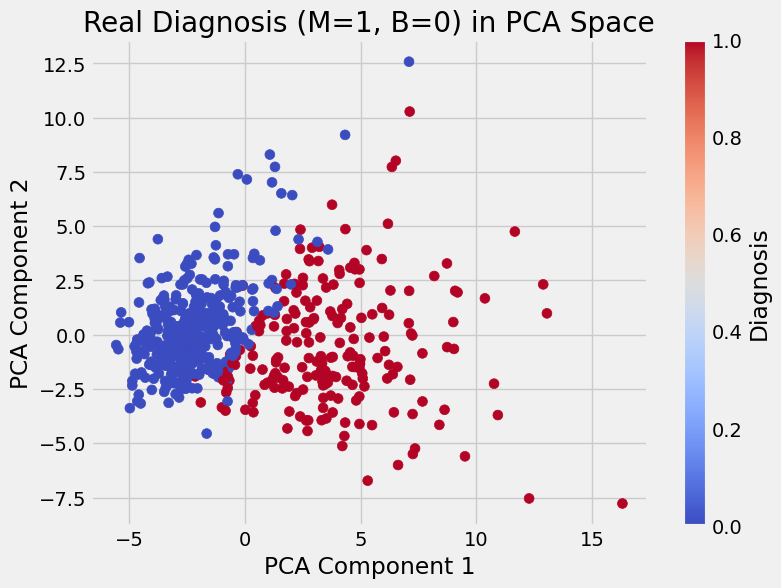

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Asegurarse de que X esté definido (es el dataset original)
# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducimos dimensiones con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Mapear Diagnosis (M/B) a números para colores
# Nota: y ya está codificado como 0 y 1, pero vamos a obtener etiquetas originales
y_original_labels = le.inverse_transform(y)
y_numeric = pd.Series(y_original_labels).map({'M': 1, 'B': 0})

# Graficar
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', s=50)
plt.title('Real Diagnosis (M=1, B=0) in PCA Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Diagnosis')
plt.show()


# **XGBOOST (Punto extra)**

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    max_depth=4,           # Árboles más pequeños (controla complejidad)
    learning_rate=0.1,     # Paso de aprendizaje más bajo
    n_estimators=100,      # Número de árboles
    reg_alpha=0.5,         # L1 regularization (puedes subirlo a 1 si hay overfitting)
    reg_lambda=1.0,        # L2 regularization
    subsample=0.8,         # Solo usa el 80% de datos por árbol
    colsample_bytree=0.8   # Solo usa el 80% de features por
    )

# Entrenar
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:19:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

reg_alpha=0.5 Reduce el impacto de features menos útiles (sparse solution).

reg_lambda=1.0 Controla los pesos grandes y ayuda a generalizar.

subsample=0.8 Hace que cada árbol vea solo parte de los datos, evitando memorizar.

colsample_bytree=0.8 Igual, pero sobre las columnas (features), ayuda contra overfitting.

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:19:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


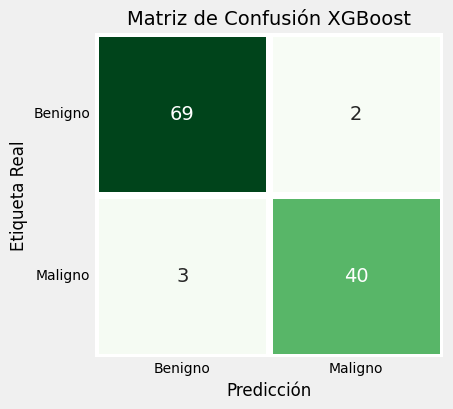


Precision: 0.9524
Recall:    0.9302
F1 Score:  0.9412
Accuracy:  0.9561


In [ ]:
# Instala XGBoost si no está instalado
!pip install xgboost

# Importar XGBoost y métricas
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Crear el modelo
xgb_model = xgb.XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')

# Entrenar el modelo
xgb_model.fit(X_train, y_train)

# Predecir
y_pred = xgb_model.predict(X_test)

import matplotlib.pyplot as plt


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# DataFrame con etiquetas reales
df_cm = pd.DataFrame(cm, index=["Benigno", "Maligno"], columns=["Benigno", "Maligno"])

# Plot
plt.figure(figsize=(4,4))
sns.heatmap(df_cm, annot=True, cmap="Greens", fmt='d',
            linewidths=5, cbar=False, annot_kws={"size": 14})
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Etiqueta Real", fontsize=12)
plt.title("Matriz de Confusión XGBoost", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.show()

# Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")


# **GMM (Punto extra)**

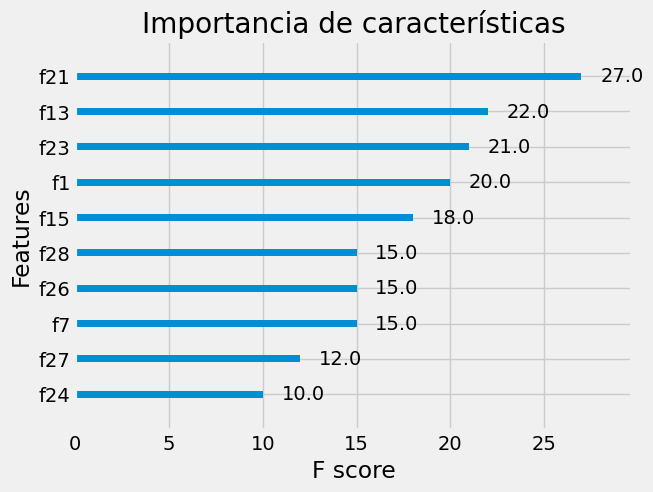

In [ ]:
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title("Importancia de características")
plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from ucimlrepo import fetch_ucirepo
from sklearn.decomposition import PCA

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

X.shape

y.value_counts()

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

cuántos subgrupos posibles hay → el número de componentes donde BIC/AIC es mínimo es el mejor candidato.

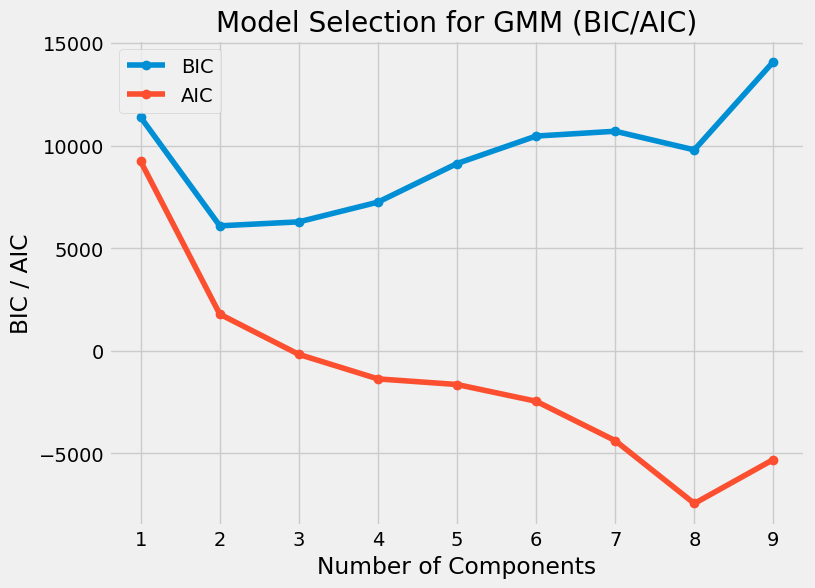

In [ ]:
bic = []
aic = []
n_components_range = range(1, 10)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))
    aic.append(gmm.aic(X_scaled))

# Graficar BIC y AIC
plt.figure(figsize=(8,6))
plt.plot(n_components_range, bic, label='BIC', marker='o')
plt.plot(n_components_range, aic, label='AIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC / AIC')
plt.title('Model Selection for GMM (BIC/AIC)')
plt.legend()
plt.show()

El número óptimo de componentes fue seleccionado en base al criterio de AIC, priorizando la capacidad de descubrir subgrupos clínicamente relevantes.

En este contexto, usar el número que da AIC (8 componentes) es mejor para exploración de subgrupos → porque:



*   AIC permite modelos más ricos (más subgrupos).
*   Como estás buscando posibles subgrupos biológicos, no te importa tanto la penalización de complejidad.



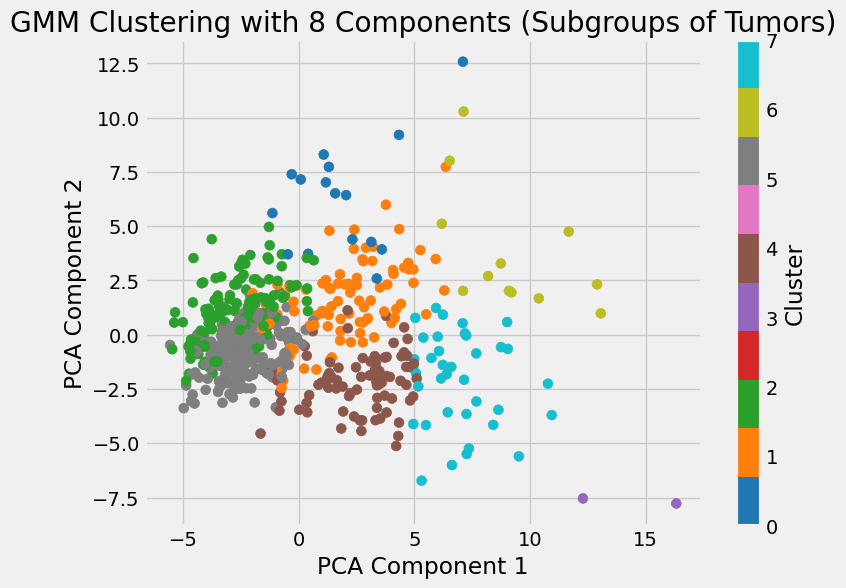

In [ ]:
optimal_n = 8  #En base al criterio AIC

gmm = GaussianMixture(n_components=optimal_n, random_state=42)
gmm.fit(X_scaled)
clusters = gmm.predict(X_scaled)

# Visualizar subgrupos en PCA 2D
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=50)
plt.title(f'GMM Clustering with {optimal_n} Components (Subgroups of Tumors)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# Calcular el Silhouette Score
silhouette = silhouette_score(X_scaled, clusters)

print(f'Silhouette Score: {silhouette:.3f}')


Silhouette Score: 0.128


In [ ]:
from sklearn.metrics import adjusted_rand_score

# Mapear Diagnosis a números (si no lo habías hecho)
y_numeric = y['Diagnosis'].map({'M': 1, 'B': 0})

# Calcular ARI
ari = adjusted_rand_score(y_numeric, clusters)

print(f'Adjusted Rand Index (ARI): {ari:.3f}')


Adjusted Rand Index (ARI): 0.321
